# FSMN-AE (paper model) — Metrics

Evaluate a model trained with `train_fsmn.py` — the FlexRay lightweight intrusion
detector of Zhou, Zhang & Yang (IEEE Access, 2026), adapted to **translated CAN data**.

This notebook:
1. Loads the trained bundle (`checkpoints/fsmn_ae_*`) and its scaler
2. Loads held-out parquet telemetry and builds sequence windows using the **saved** scaler
3. Injects synthetic attacks (dos / fuzzing / spoof / spike / drift / frequency / replay / splice)
4. Scores benign vs attack windows with the **reconstruction-error head** and the paper's
   dynamic threshold theta = mu + k.sigma
5. Reports PR AUC, macro F1, AUROC, recall/FPR, per-attack breakdown, latency
6. Highlights the **lightweight footprint** (parameter count / KiB) — the paper's headline claim

> Run from `Python scripts/fsmn_ae_v1/` so `fsmn_model`, `train_fsmn`, `evaluate_fsmn` import.
> Requires: `pip install numpy pandas pyarrow scikit-learn matplotlib "jax[cpu]" flax optax`

## 1. Configuration

Point these at your trained bundle and evaluation parquet data. Defaults match `train_fsmn.py`.

In [1]:
from pathlib import Path

# Model bundle produced by train_fsmn.py
BUNDLE_DIR = Path("checkpoints")
NAME       = "fsmn_ae"

# Parquet file or folder to evaluate on (ideally held out from training)
DATA_PATH = Path("../../Data/new_data_processed")

MAX_EVAL_WINDOWS = 20_000   # cap for speed (uniform subsample across trace)
ATTACK_RATE      = 0.30     # attack windows injected, as a fraction of benign windows
SEED             = 42

## 2. Imports & load the trained bundle

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score, f1_score, roc_auc_score,
    precision_recall_curve,
)

from fsmn_model import FSMNAE, FEATURES, N_FEATURES, WINDOW_SIZE, STRIDE
from train_fsmn import load_parquet, make_windows          # reuse loaders
from evaluate_fsmn import SINGLE_ATTACKS, PAIR_ATTACKS, ATTACKS, build_attack_set

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

model = FSMNAE.load(str(BUNDLE_DIR), name=NAME)
scaler = np.load(BUNDLE_DIR / f"{NAME}_scaler.npz")
MU, SD = scaler["mean"].astype(np.float32), scaler["std"].astype(np.float32)

print(f"Loaded bundle: {BUNDLE_DIR.resolve()} ({NAME})")
print(f"  config          : {model.cfg}")
print(f"  parameters      : {model.num_params():,}  (~{model.approx_size_kb():.1f} KiB float32)")
print(f"  dynamic thr     : theta = mu + k.sigma = {model.err_mean:.6f} "
      f"+ {model.k}*{model.err_std:.6f} = {model.recon_threshold:.6f}")
print(f"  scaler mean     : {np.round(MU, 3)}")
print(f"  scaler std      : {np.round(SD, 3)}")

Loaded bundle: /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/fsmn_ae_v1/checkpoints (fsmn_ae)
  config          : FSMNAEConfig(window=50, n_features=8, enc_dims=(64, 32, 16), code_dim=16, fsmn_order=10, fsmn_order_fwd=0, dropout=0.1, activation='relu')
  parameters      : 7,080  (~27.7 KiB float32)
  dynamic thr     : theta = mu + k.sigma = 0.012232 + 2.5*0.009595 = 0.036219
  scaler mean     : [ 2.0170e+01  5.8624e+01  3.0200e-01  2.5900e-01 -1.3000e-02  1.3820e+00
  1.8137e+01  3.6473e+01]
  scaler std      : [1.2309e+01 2.6495e+01 2.3600e-01 4.3400e-01 3.8000e-02 5.9000e-01
 8.8450e+01 7.1065e+01]


## 3. Load parquet & build windows (using the saved scaler)

Sequence windows are shape `(N, WINDOW_SIZE, N_FEATURES)`. We normalise with the
**training** mean/std so the calibrated dynamic threshold stays valid.

In [3]:
trace = load_parquet(DATA_PATH)
norm = ((trace - MU) / SD).astype(np.float32)
benign = make_windows(norm, STRIDE)
print(f"[Windows] {len(benign):,} benign (stride={STRIDE})")

if len(benign) > MAX_EVAL_WINDOWS:
    idx = np.linspace(0, len(benign) - 1, MAX_EVAL_WINDOWS, dtype=int)
    benign = benign[idx]
    print(f"[Windows] subsampled to {len(benign):,}")

[Data] loaded 3,160,814 rows from 103 file(s)
[Data] using columns:  speed_kmh<-speed_kmh, battery_level<-battery_level, throttle<-throttle, brake<-brake, steering<-steering, gear<-gear, location_x<-location_x, location_y<-location_y
[Windows] 158,039 benign (stride=20)
[Windows] subsampled to 20,000


## 4. Inject synthetic attacks

Attacks operate on z-scored windows; magnitudes are in standard deviations — the same
eight families and definitions as `vae_v1`, so the two models are compared on identical
perturbations (the paper's DoS / Fuzzing / Spoofing plus temporal manipulations).

In [4]:
windows, labels, kinds = build_attack_set(benign, rng, ATTACK_RATE)
prevalence = float(labels.mean())
print("[Attacks] " + ", ".join(f"{k}={int((kinds == k).sum())}" for k in ATTACKS))
print(f"[Test] benign={int((labels == 0).sum()):,}  attack={int((labels == 1).sum()):,}"
      f"  prevalence={prevalence:.3f}")

[Attacks] dos=750, fuzzing=750, spoof=750, spike=750, drift=750, frequency=750, replay=750, splice=750
[Test] benign=20,000  attack=6,000  prevalence=0.231


## 5. Score every window (reconstruction head)

The FSMN-AE has a **single** detection head: per-window reconstruction MSE, compared
against the dynamic threshold theta = mu + k.sigma (paper Eq. 4). This differs from the
sibling `vae_v1`, which adds two encoder-only latent heads.

In [5]:
recon_scores = model.reconstruction_error(windows)
recon_pred   = (recon_scores > model.recon_threshold).astype(int)

HEADS = {
    "Reconstruction": (recon_scores, recon_pred, model.recon_threshold),
}
print("scored", len(windows), "windows")

scored 26000 windows


## 5b. Detection latency & lightweight footprint

The paper's central claim is *resource efficiency*: fewer parameters, less memory, faster
than GRU-/LSTM-based autoencoders.

**Latency** uses the same **streaming** protocol as `mvp_v1/evaluate_central.ipynb`:
score one window per call, time each call, report **p50 / p99** (after JIT warm-up).
The footprint is the exact learnable-parameter count and its float32 size — compare
these against the `mvp_v1` GRU-AE and `vae_v1` LSTM-VAE.

In [6]:
import time

# Warm up JIT, then streaming protocol (same as mvp_v1): one window per call.
model.reconstruction_error(windows[:64])

lat_us = np.empty(len(windows), dtype=np.float32)
for i in range(len(windows)):
    t0 = time.perf_counter()
    model.reconstruction_error(windows[i:i + 1])
    lat_us[i] = (time.perf_counter() - t0) * 1e6

lat_p50 = float(np.percentile(lat_us, 50))
lat_p99 = float(np.percentile(lat_us, 99))

print(f"parameters            : {model.num_params():,}")
print(f"approx float32 size   : {model.approx_size_kb():.1f} KiB")
print(f"latency p50={lat_p50:.1f}µs  p99={lat_p99:.1f}µs")

parameters            : 7,080
approx float32 size   : 27.7 KiB
batched latency       : 3.25 +/- 0.05 us/window


## 6. Headline metrics (PR AUC + macro F1)

In [7]:
rows = []
for name, (scores, pred, thr) in HEADS.items():
    rows.append({
        "head": name,
        "PR AUC": average_precision_score(labels, scores),
        "macro F1": f1_score(labels, pred, average="macro", zero_division=0),
        "AUROC": roc_auc_score(labels, scores),
        "recall": float(pred[labels == 1].mean()),
        "FPR": float(pred[labels == 0].mean()),
        "latency p50 (µs)": lat_p50,
        "latency p99 (µs)": lat_p99,
    })
summary = pd.DataFrame(rows).set_index("head")
print(f"random-baseline PR AUC = prevalence = {prevalence:.3f}\n")
summary.round(3)

random-baseline PR AUC = prevalence = 0.231



,PR AUC,macro F1,AUROC,recall,FPR,latency (us/win)
head,,,,,,
Reconstruction,0.749,0.821,0.803,0.57,0.012,3.252


## 7. Precision-Recall curve

PR AUC (average precision) is the primary metric for imbalanced detection. The dashed
line is the random baseline (= attack prevalence).

> **Reading the curve.** The reconstruction head sits near **precision ~ 1.0** for the
> large-magnitude, widespread attacks (DoS, fuzzing, spoofing) that blow up the MSE, then
> **drops toward the baseline** for subtle temporal attacks (spike, drift, frequency,
> replay, splice) that barely move a window-averaged error. This step shape is expected —
> it is exactly the reconstruction-only limitation the FlexRay paper accepts in exchange
> for its tiny footprint (it has no latent heads to recover the subtle cases).
> If the curve is instead flat at baseline everywhere with training loss stuck near ~1.0,
> that is posterior/identity collapse: train more epochs or lower the L1 penalty (`--l1`).

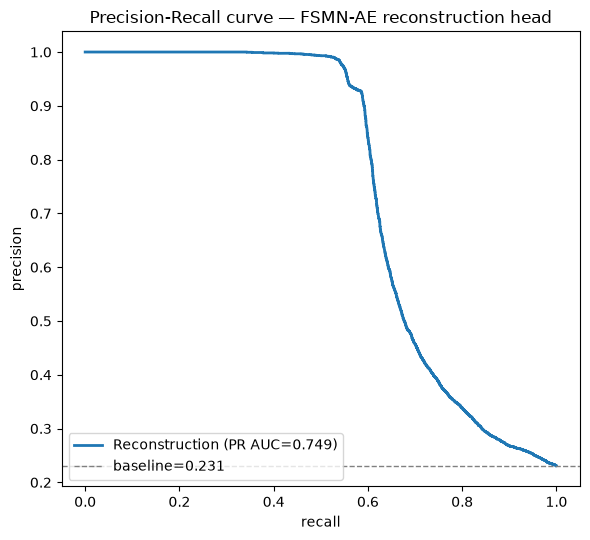

In [8]:
fig, ax = plt.subplots(figsize=(6, 5.5))
for name, (scores, pred, thr) in HEADS.items():
    prec, rec, _ = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)
    ax.plot(rec, prec, lw=2, label=f"{name} (PR AUC={ap:.3f})")
ax.axhline(prevalence, ls="--", color="gray", lw=1, label=f"baseline={prevalence:.3f}")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision-Recall curve — FSMN-AE reconstruction head")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 8. Score distribution (benign vs attack)

The red dashed line is the dynamic threshold theta = mu + k.sigma.

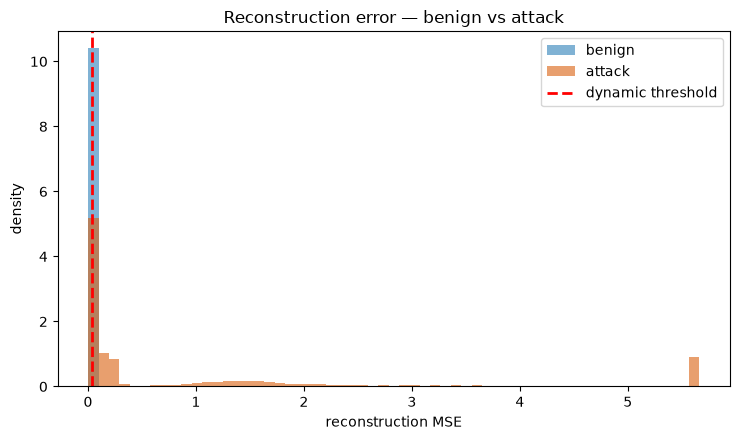

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
scores, pred, thr = HEADS["Reconstruction"]
b = scores[labels == 0]
a = scores[labels == 1]
lo, hi = np.percentile(scores, 1), np.percentile(scores, 99)
bins = np.linspace(lo, hi, 60)
ax.hist(b, bins=bins, alpha=0.6, density=True, color="#2c7fb8", label="benign")
ax.hist(a, bins=bins, alpha=0.6, density=True, color="#d95f0e", label="attack")
ax.axvline(thr, color="red", ls="--", lw=2, label="dynamic threshold")
ax.set_title("Reconstruction error — benign vs attack")
ax.set_xlabel("reconstruction MSE")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Per-attack PR AUC (each family vs benign)

Threshold-independent — shows how detectable each attack family is for the reconstruction head.

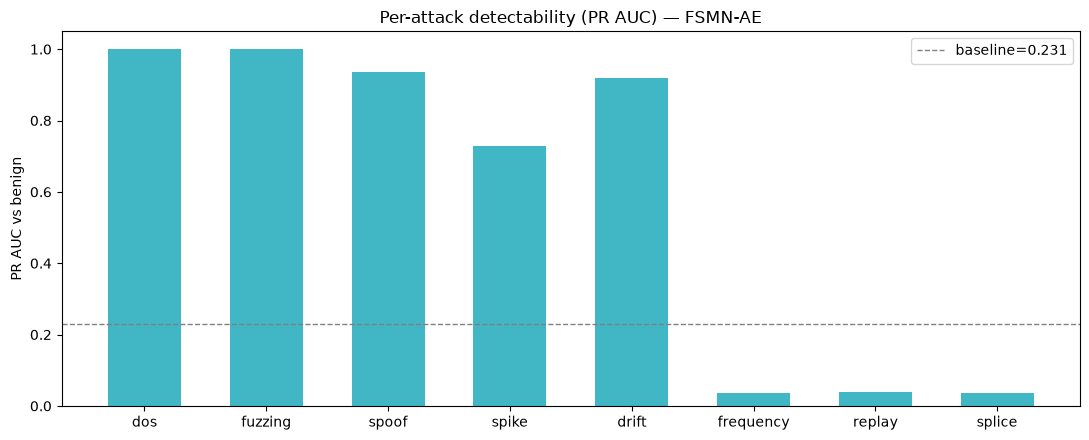

,Reconstruction
attack,
dos,1.000
fuzzing,1.000
spoof,0.936
spike,0.728
drift,0.918
frequency,0.037
replay,0.038
splice,0.035


In [10]:
rows = []
for k in ATTACKS:
    m = (kinds == k) & (labels == 1)
    if not m.any():
        continue
    benign_s = recon_scores[labels == 0]
    y = np.concatenate([np.zeros(len(benign_s)), np.ones(int(m.sum()))])
    s = np.concatenate([benign_s, recon_scores[m]])
    rows.append({"attack": k, "Reconstruction": average_precision_score(y, s)})
per_attack = pd.DataFrame(rows).set_index("attack")

x = np.arange(len(per_attack))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x, per_attack["Reconstruction"], 0.6, color="#41b6c4")
ax.axhline(prevalence, color="gray", ls="--", lw=1, label=f"baseline={prevalence:.3f}")
ax.set_xticks(x, per_attack.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("PR AUC vs benign")
ax.set_title("Per-attack detectability (PR AUC) — FSMN-AE")
ax.legend()
plt.tight_layout()
plt.show()

per_attack.round(3)

## 10. Reading the results

- **PR AUC** and **macro F1** are the metrics for this imbalanced setting. PR AUC well
  above the prevalence baseline means the reconstruction error ranks attacks above benign.
- **recall / FPR** are at the dynamic threshold theta = mu + k.sigma. Raise/lower `--k` in
  `train_fsmn.py` to trade FPR against recall (the paper sweeps k in {1.5, 2, 2.5, 3, 3.5}
  and picks 2.5).
- **Latency p50 / p99** use the same streaming protocol as `mvp_v1` (one window per call),
  so they are comparable across models. The parameter count / KiB figure is the separate
  lightweight footprint claim.
- The FSMN-AE trades the latent heads of `vae_v1` for a much smaller model. Compare
  detection quality vs footprint against `mvp_v1` (GRU-AE) and `vae_v1` (LSTM-VAE).
- A per-attack PR AUC near the baseline means that family is effectively invisible to the
  window-averaged reconstruction error (expected for subtle single-cell temporal attacks).